(understanding_data)=
# Understanding data
One of the biggest issues with data analysis in the biological sciences is that many scientists do not understand the fundamentals of their own data. The reason this problem exists is the most common plotting and statistics program used by scientists is not flexible enough to really explore data in a meaningful way. Additionally, there are usually no courses on data analysis that focus on practicality and intuition. Courses typically get bogged down in mathematics which I do not think you need to start to understand your data. Here, we are going to cover how to describe basic data types and how to visualize data so we can see what our data is like. There are several data types you will encounter, namely continuous, count and categorical. Describing the data type your data is relies on understand how your data is generated and should be done before visualizing and running analysis/statistics on your data.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bokeh.io import output_notebook, show
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Select, Whisker
from bokeh.plotting import figure
from lithos import CategoricalPlot, LinePlot
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

cwd = Path.cwd().parent / "data/pv"
df = pd.read_csv(cwd / "mini_data.csv")

consumption = pd.read_csv(
    Path().cwd().parent / "data/stats/regression_as_generative.csv"
)
consumption["con_log"] = np.log10(consumption["consumption"])

output_notebook()

Loading BokehJS ...

## Contiuous data
Continuous values can take on any infinity small decimal point between two real values compared to discrete values which are limited to specific steps (see [Wikipedia](https://en.wikipedia.org/wiki/Continuous_or_discrete_variable)). Membrane resistance, rheobase, time in an area, etc are all continuous data. Continuous data has two main features; bounds and shape. Sometimes we have a theoretically continuous variable that ends up more discrete due to how we collect the data. For example, rheobase is discretized by using a limited number of current injection steps. Discretized values are more likely to be repeated in a dataset than continuous values. However, we usually treat values that have been discretized by data collection methods as continuous.

### Bounds 
A lot of scientific data has bounds on the possible values that the data can be. Typical bounds can be from ($-\infty$, $\infty$), (0, $-\infty$) or (0,1). For example membrane resistance cannot be less than zero but can go to infinity. Spike threshold could technically be negative or positive even though it is unlikely to be positive, so it is unbounded theoretically but bounded biologically. Time values are continuous but become discrete to digitization. Some values become artificially bounded by our ability to detect. mEPSC amplitude cannot be below zero pA however we often set an analysis cutoff above zero pA which truncates the data. Sometimes truncation can cause problems for analysis if the truncation is too sharp in which case you may need to redesign your experiment.
### Shape
When we have continuous or near continuous data we can also describe the data by its shape. Most shape measures assume your data is continuous so be careful when you have count data. The shape of our data can be seen by plotting our data as will as describing our data. If you have some form of categorical data your data does not have shape and visualization will be much different.
#### Location
Location can be thought of as an additive parameter that shifts the data along the x-axis without changing is shape. To shift the location of your data just added or subtract a constant value. The **mean** and **median** are considered location parameters.
#### Scale
Scale relates to the range of values you are likely to get from your data and is probably the most important feature of our data. If you multiply, divide or log transform your data, you are changing the scale of your data. The standard deviation is an example of scale. The larger the standard deviation is the larger the values you have. Quantiles/percentiles are another common value that can discribe the scale of your data. Also note that the standard error of the mean (SEM) is not a scale measure but a precision measure. Lastly, most statistic tests we use assume that the scale is the same between the groups. When the scale is not the same between our groups we cannot use most basic statistical test unless we can transform our data so that the scale is the same.
#### Shape
The shape is how wide or narrow, skewed right or left your data is. It will change the central tendency (most common value) of the distribution but not in the way location does. Shape is a not related to shifting your data.
#### Skew
[Skew](https://en.wikipedia.org/wiki/Skewness) is whether the data tends have more low values than high values or vice versa if your were to split your data by the mean. The shape and scale of a distribution often interact to change a distribution's skew. Skew can be measured by comparing the distance between 0.75 quantile and median, and the 0.25 quantile and the median or by using the Scipy function [skew](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html) which uses a moments formula. It is also important to note that skewness measures often fail for multimodal distributions. A common method to measure the skew using the mean and median fails for multimodal distribution.
```{image} ../data/skew.svg
:alt: Plotted examples of skewed data
:align: center
```
#### Kurtosis
Kurtosis is the tailedness of your data. Long tails increase the chance of getting extreme values. Sometimes we call these outliers. Shape and scale often interact to change a distribution's kurtosis. Kurtosis can be measured using the Scipy function [kurtosis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html#scipy.stats.kurtosis).
```{image} ../data/kurtosis.svg
:alt: Plotted examples of kurtotic data
:align: center
```

### Plotting continuous data
The most common ways to plot data are to use a error bars plus measure of centrality, box plots, histogram or KDE (note: violin plot is just a KDE). All these methods are non-parametric in that they technically do not have any parameters other than your data to create a distribution. Each method has benefits and draw backs. Error bars plus measure of centrality are the most common but least informative since they usually do no convey information about the shape of the data. Errors bars can show the SEM (not very informative), standard deviation (better), confidence intervals (bootstrapped ared the best) and precentiles (will show the shape of the data). Box plots can convey information about the shape of the data but need more data points than error bars. Box plots show the median, sometimes the mean, the 0.25 and 0.75 quantile and 1.5 times the interquartile range. Histograms are good for larger amounts of data but can be biased by bin width (0-1, 1-2, etc.). KDE needs larger amounts of data but have the least amount of bias. Note that you can turn histograms and KDEs onto their side for typical categorical data.

#### How to create a box plot
A box plot consists of a box that goes from the 0.25 quantile to the 0.75 quantile. There is a line in the middle that is the 0.5 quantile or median. There are whiskers that can be plotted one of two ways. One way is to use the interquartile range (IQR) as is or you can calculate use the minimum point that is closest to the IQR which is useful if the IQR goes beyond any values in your data. The IQR is the difference between 0.75 and 0.25 quantiles times 1.5. Then you add that to the 0.75 quantile or subtract that from the 0.25 quantile.

In [ ]:
def box(data):
    q1, q2, q3 = np.quantile(data, q=[0.25, 0.5, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    wiskhi = data.loc[(q3 <= data) & (data <= upper)]
    wiskhi = [q3 if len(wiskhi) == 0 else wiskhi.max()]
    wisklo = data[(lower <= data) & (data <= q1)]
    wisklo = [q1 if len(wisklo) == 0 else wisklo.min()]
    return q1, q2, q3, wiskhi, wisklo

#### How to Create a Histogram
To create a histogram in Python the easiest way is to use Numpy's [histogram](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html). For this example we will use 50 bins, however Numpy has a pretty good algorithm for automatically selecting bins. One setting we will use is the density equals true. This will ensure that each bin shows the likelihood so that is matches with the KDE. If you just want to plot a histogram in other popular plotting packags such as Matplotlib or Seaborn, they have modules where you can just put in your data.

In [ ]:
def hist(data):
    hist, edges = np.histogram(
        data, range=(data.min() - 1e-6, data.max() + 1e-6), density=True, bins=50
    )
    return hist, edges

#### How to Create a Kernel Density Estimate (KDE)
To create a KDE in Python we are going to use Scipy's [gaussian_kde](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html). There are other implementations of KDEs such  [Scikit Learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html) and [KDEpy](https://kdepy.readthedocs.io/en/latest/index.html).

KDE stands for Kernel Density Estimate. KDE is a non-parametric density function. There is no predefine function to create the PDF from your data, you create a unique one from your data. The aim of the KDE is not to represent the density function of your data exactly as it is, like a histogram but, to represent it as if you had an infinitely large sample size. KDEs can represent your data as it is by setting a feature called the bandwidth. The only real subjective feature of a KDE is how much to "smooth" your probability distribution that the KDE outputs. 

The KDE works by essiantially putting a gaussian distribution (or other distribution) around each point of data and then sums them up. Depending on how smooth we want the distribution we can increase or decrease the bandwidth. For the gaussian distribution the bandwidth is related to the standard deviation. The larger the bandwidth the smoother the KDE and vice versa. There are some algorithms to precompute the bandwidth called Silvermans, Scotts and Improved Sheather-Jones (ISJ) if you don't want to compute the bandwidth yourself however, Scipy does not provide the ISJ algorithm. There are also different ways to compute the KDE such tree and FFT.

In [ ]:
def kde(data):
    min_val = min(data)
    max_val = max(data)
    padding = (max_val - min_val) * 0.1  # Add 10% padding
    grid_min = min_val - padding
    grid_max = max_val + padding
    grid_min = max(grid_min, 0)
    positions = np.linspace(grid_min, grid_max, num=248)
    kernel = stats.gaussian_kde(data)
    y = kernel(positions)
    return positions, y

Below we will process all the data.

In [ ]:
box_dict = {}
kde_dict = {}
hist_dict = {}

columns = [
    "Est Tau (ms)",
    "Rise Time (ms)",
    "Rise Rate (pA/ms)",
    "Amplitude (pA)",
    "IEI (ms)",
]

for i in columns:
    data = df[i]
    if i == "IEI (ms)":
        data = data[data > 0]
    for f, n in [(lambda x: x, "identity"), (np.sqrt, "sqrt"), (np.log, "log")]:
        q1, q2, q3, wiskhi, wisklo = box(f(data))
        box_dict[f"{i}_q1_{n}"] = [q1]
        box_dict[f"{i}_q2_{n}"] = [q2]
        box_dict[f"{i}_q3_{n}"] = [q3]
        box_dict[f"{i}_u_{n}"] = wiskhi
        box_dict[f"{i}_l_{n}"] = wisklo

        positions, y = kde(f(data))
        kde_dict[f"{i}_x_{n}"] = positions
        kde_dict[f"{i}_y_{n}"] = y

        hist_data, edges = np.histogram(
            f(data),
            range=(f(data.min()) - 1e-6, f(data.max()) + 1e-6),
            density=True,
            bins=50,
        )
        hist_dict[f"{i}_hist_{n}"] = hist_data
        hist_dict[f"{i}_left_{n}"] = edges[:-1]
        hist_dict[f"{i}_right_{n}"] = edges[1:]

box_dict["q1"] = box_dict["Amplitude (pA)_q1_identity"]
box_dict["q2"] = box_dict["Amplitude (pA)_q2_identity"]
box_dict["q3"] = box_dict["Amplitude (pA)_q3_identity"]
box_dict["u"] = box_dict["Amplitude (pA)_u_identity"]
box_dict["l"] = box_dict["Amplitude (pA)_l_identity"]

kde_dict["kde_y"] = kde_dict["Amplitude (pA)_y_identity"]
kde_dict["x"] = kde_dict["Amplitude (pA)_x_identity"]

hist_dict["left"] = hist_dict["Amplitude (pA)_left_identity"]
hist_dict["right"] = hist_dict["Amplitude (pA)_right_identity"]
hist_dict["hist_y"] = hist_dict["Amplitude (pA)_hist_identity"]

#### Examining the data
Below are some plots of our data using the plotting methods from above. There are two common transforms that we include and explain more below. Look at the data and see how they change. You will also notice I included some lines in the KDE plot. The magenta line would be considered the mode, or the most common value, the blue line is the median and the orange line is the mean. Look at what happens to the relationship between those lines with the different transforms.

In [ ]:
menu = Select(title="Variables", value="IEI (ms)", options=columns)
kde_source = ColumnDataSource(kde_dict)
hist_source = ColumnDataSource(hist_dict)
box_source = ColumnDataSource(box_dict)
transform = Select(
    title="Transform",
    value="identity",
    options=["identity", "sqrt", "log"],
)

hist_figure = figure(height=200, width=250, title="Histogram")
hist_data = hist_figure.quad(
    top="hist_y",
    bottom=0,
    left="left",
    right="right",
    line_color="white",
    alpha=0.5,
    source=hist_source,
)

kde_figure = figure(height=200, width=250, title="KDE")
line = kde_figure.line(x="x", y="kde_y", source=kde_source, line_color="black")

box_figure = figure(
    height=200,
    width=250,
    title="Box",
    y_range=(box_source.data["l"][0] * 0.8, box_source.data["u"][0] * 1.1),
)
whisker = Whisker(base=0, upper="u", lower="l", source=box_source)
whisker.upper_head.size = whisker.lower_head.size = 20
box_figure.add_layout(whisker)
box_figure.vbar(0, 1, "q2", "q3", source=box_source, color="orange", line_color="black")
box_figure.vbar(0, 1, "q1", "q2", source=box_source, color="orange", line_color="black")

central_tendency = {}
for i in columns:
    data = df[i]
    if i == "IEI (ms)":
        data = data[data > 0]
    index = kde_source.data[f"{i}_y_identity"].argmax()
    central_tendency[f"{i}_identity"] = [
        np.mean(data),
        np.median(data),
        kde_source.data[f"{i}_x_identity"][index],
    ]
    sqrt_data = np.sqrt(data)
    index = kde_source.data[f"{i}_y_sqrt"].argmax()
    central_tendency[f"{i}_sqrt"] = [
        np.mean(sqrt_data),
        np.median(sqrt_data),
        kde_source.data[f"{i}_x_sqrt"][index],
    ]
    log_data = np.log(data)
    index = kde_source.data[f"{i}_y_log"].argmax()
    central_tendency[f"{i}_log"] = [
        np.mean(log_data),
        np.median(log_data),
        kde_source.data[f"{i}_x_log"][index],
    ]
central_tendency["x"] = central_tendency["Amplitude (pA)_identity"]
central_tendency["color"] = ["orange", "blue", "magenta"]
central_tendency = ColumnDataSource(central_tendency)

vspans = kde_figure.vspan(x="x", color="color", source=central_tendency)

callback = CustomJS(
    args={
        "hist_source": hist_source,
        "kde_source": kde_source,
        "box_source": box_source,
        "box_figure": box_figure,
        "central_tendency": central_tendency,
        "menu": menu,
        "transform": transform,
    },
    code="""
    hist_source.data.hist_y = hist_source.data[`${menu.value}_hist_${transform.value}`]; 
    hist_source.data.left = hist_source.data[`${menu.value}_left_${transform.value}`]; 
    hist_source.data.right = hist_source.data[`${menu.value}_right_${transform.value}`]; 
    kde_source.data.kde_y = kde_source.data[`${menu.value}_y_${transform.value}`];
    kde_source.data.x = kde_source.data[`${menu.value}_x_${transform.value}`];
    central_tendency.data.x = central_tendency.data[`${menu.value}_${transform.value}`];
    box_source.data.q1 = box_source.data[`${menu.value}_q1_${transform.value}`];
    box_source.data.q2 = box_source.data[`${menu.value}_q2_${transform.value}`];
    box_source.data.q3 = box_source.data[`${menu.value}_q3_${transform.value}`];
    box_source.data.u = box_source.data[`${menu.value}_u_${transform.value}`];
    box_source.data.l = box_source.data[`${menu.value}_l_${transform.value}`];
    box_figure.y_range.start = box_source.data.l[0] - box_source.data.l[0] * 0.5
    box_figure.y_range.end = box_source.data.u[0] * 1.1
    central_tendency.change.emit();
    kde_source.change.emit();
    hist_source.change.emit();
    box_source.change.emit();
""",
)

menu.js_on_change("value", callback)
transform.js_on_change("value", callback)

show(column(row(menu, transform), row(hist_figure, kde_figure, box_figure)))

### Transforms
In the plots above, what did you notice when the data transformed? You may have noticed that the whiskers in the box plot become more symmetrical. You may have noticed that the the mean and median lines in the KDE plot get closer together with the square root and log transform. The mean and median also get closer to the mode. When dealing with non-gaussian continuous data we can transform the data to make it gaussian. Perfect gaussian data should have no difference between the mean, median and mode. Most transforms work only with positively skewed data. To transform negatively skewed data we often have to multiply by negative 1. All transforms rescale the data to get it to be more guassian but, the best transforms have interpertability for inferential statistics. Transforms also allow us to use simple statistical models (OLS) rather than relying on more complex models (GLMs). When modeling data we are usually looking for the simplest model to accurately models our data since simple models are much more interpretable.
#### Square root transform
The square root transform is probably the least "strong" common transform for positive skew data.
#### Log transform
The log transform is by far the most useful transform for positive skew data. The log transform works on data that is bounded by zero and goes to positive infinity. You can use any type of base for the log however, the natural log is probably the most common. The log transform is nice because if you log transform normal data is will just be normally distributed. So you could theoretically just log transform everything since in with real data the the `np.mean(x)` and `np.exp(np.mean(np.log(x)))` will almost never be the same but very close.
#### Negative inverse (or the inverse)
Good for strongly positive skewed data and also keeps interpretability of a regression model. We take the negative inverse because this keeps the directionality of the data (large values are large and small values are small). Rheobase and membrane resistance are inversely related so if you want to run a correlation between the two this is a good choice.
#### Box-cox
Box-Cox can only be used on positive data and automatically finds the best power transform for positively or negatively skew data.
#### Yeo-Johnson
Similar to Box-Cox but works with negative data on positively or negatively skew data.
#### Power transform
All the transforms we covered are actually specific instances of a power transform. Power transform is just `x**y` where `y` is any number. For example the power transform can be the square `x**(1/2)` or the cube `x**3`
Transform for data that includes negative numbers and is similar to the log transform.
#### Rank transform
This is more "exotic" transform in that it you lose a lot of interpetibility since it changes based on what data you put in. It is more common in the machine learning field but works well for extremely kurtotic data and works with extreme skew and multimodal data.

### Working with summary data vs large data.
Summary data is essentially the mean, median, mode, quantile, etc at the level you want to run statistics on. For example, summary data is we get want get a single summary IEI value for a cell with 1000 mEPSC IEIs. The question is how to work with unsummarized data and how to work with the summary data. Working with unsummarized data presents a lot of challenges. The unsummarized data is very often non-gaussian and you would need to run hierarchical/mixed model statistics on that data. Additionally, the hierarchical/mixed models have questionable p-values since they tend to over estimate effect sizes due to assumptions they make about something called asymmptotic behavior of distributions (what happens when your sample size is assumed to infinitely large). We will cover more about those in the statistics chapter. So often the best choice is to summarized data like IEIs. The nice thing is that summarized data is often gaussian due to something called the [central limit theorem](https://en.wikipedia.org/wiki/Central_limit_theorem) where the distribution of sample means (means of each cell's IEI distribution) will be normal. Summarized data is often beneficial since you can use simpler statistics which often have better interpretability. 
The bigger question is really what is a good way to summarize your data. For example if you take the mean of skewed data then the mean is heavily influenced by outliers. Other measures like the median will not guarantee the central limit theorem but may be a better discriptor or your data. The first thing is to look at the distribution of values for a difference subjects (cells, mice, etc). Check for normality. If the data is not normal try transforming with a log transform. If the log transform "normalizes" the data then get the mean and take the exponential to back transform it.

### Multimodal data
Multimodal data is probably more common than you think. I often see it with big data; IEIs for mEPSCs or spikes, mEPSC amplitude. For most experiments were we have a summary statistic at the level we run the statistical test on we generally don't see it. Multimodal data can make our data look non-gaussian when in reality the we have two or more gaussian distributions underlying the full distribution. We can also have multimodal non-gaussian distributions.

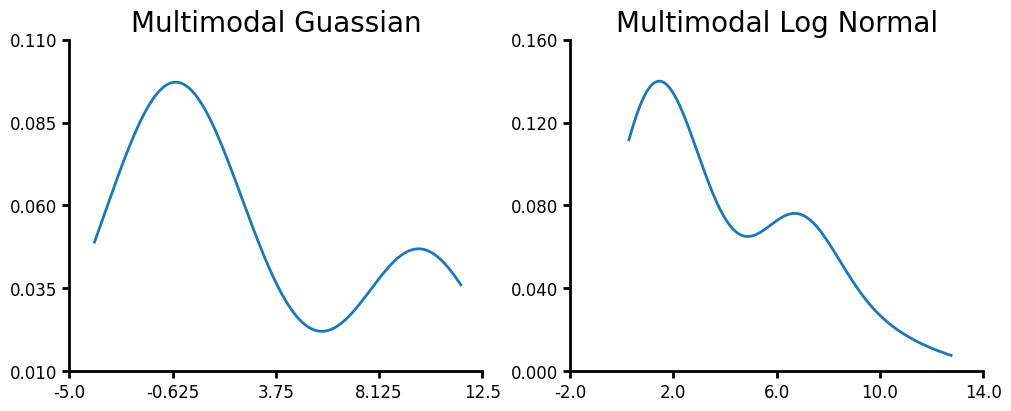

In [14]:
one = stats.norm.rvs(loc=0, scale=2, size=50, random_state=42)
two = stats.norm.rvs(loc=10, scale=1, size=20, random_state=42)
merged = np.r_[one, two]
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), layout="constrained")
plot = (
    LinePlot({"y": merged})
    .plot_data("y", title="Multimodal Guassian")
    .kde()
    .axis(ydecimals=3)
    .plot(figure=fig, axes=ax[0])
)
one = stats.lognorm.rvs(1, loc=0, scale=2, size=50, random_state=42)
two = stats.lognorm.rvs(1, loc=6, scale=1, size=20, random_state=42)
merged = np.r_[one, two]
plot = (
    LinePlot({"y": merged})
    .plot_data("y", title="Multimodal Log Normal")
    .kde()
    .axis(ydecimals=3)
    .plot(figure=fig, axes=ax[1])
)

## Examples of data principles
Next we will work on describing similarities and differences between some data sets. 
### Scale-Location differences
For this dataset on drug consumption you will notice that that the scale, or standard deviation, increases as the mean (location) increases. If scale changes with location then you know you have non-gaussian data. If you are not convinced that the mean increases with the scale we plot a regression and clearly see that the scale increases.

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), layout="constrained")
plot = (
    CategoricalPlot(consumption)
    .grouping(group="Cohort")
    .plot_data(y="consumption", ylabel="Consumption", title="Original")
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[0])
)
f = consumption.groupby(["Cohort"], as_index=False).aggregate(
    consumption_mean=("consumption", "mean"),
    consumption_std=("consumption", "std"),
    con_log_mean=("con_log", "mean"),
    con_log_std=("con_log", "std"),
)
plot = (
    LinePlot(f)
    .plot_data(
        "consumption_mean",
        "consumption_std",
        title="Original",
        ylabel="Mean",
        xlabel="STD",
    )
    .scatter()
    .fit()
    .plot(figure=fig, axes=ax[1])
)

What happens if we log transform the dataset?

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4), layout="constrained")
plot = (
    CategoricalPlot(consumption)
    .grouping(group="Cohort")
    .plot_data(y="consumption", ylabel="Consumption", title="Transformed")
    .jitter(markersize=10, width=0.6)
    .summary(barwidth=0.8, err_func="std")
    .axis(ydecimals=2)
    .transform(ytransform="ln")
    .axis_format(yminorticks=5)
    .plot(figure=fig, axes=ax[0])
)
f = consumption.groupby(["Cohort"], as_index=False).aggregate(
    consumption_mean=("consumption", "mean"),
    consumption_std=("consumption", "std"),
    con_log_mean=("con_log", "mean"),
    con_log_std=("con_log", "std"),
)
plot = (
    LinePlot(f)
    .plot_data(
        "con_log_mean",
        "con_log_std",
        title="Transformed",
        ylabel="Mean",
        xlabel="STD",
    )
    .scatter()
    .fit()
    .plot(figure=fig, axes=ax[1])
)

Now you notice that as the mean changes the standard deviation does not change. Also it is important to note that the data is transformed before the we take the mean and standard deviation. To run a statistical test we would do something similar where we would log transform before the test then "back transform" our coefficients and marginal effects.

## Count data
Count data are things like number of entries into an area, number of spikes or mEPSCs in an acquisition, number of hospital visits, etc. Count data requires specific statistical tests since the data is bounded from zero to infinity and can only be integer numbers.

## Categorical data
Categorical data is when we assign something to a non-numerical group such male/female or up/down/left/right, true/false, small/medium/large, etc. Categorical data can be ordered or unordered. Unordered would be somethign like male/female and ordered would be like small/medium/large. Sometimes the way we collect data turns a continuous variable into a categorical variable. The Von Frey test uses small wires of increasing gauge to test pain senstivity. Pain is continuous but there are only ~12 wires used for the Von Frey test and in my experience you only need about 4 different wires to find the pain threshold for a cohort of mice.